# VQC Based on IQC

## Imports

In [1]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate,Initialize
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.datasets import make_circles
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd


## Base de Dados

In [28]:
#Parâmetros
RANDOM_SEED = 1
N_SAMPLES = 2000
NOISE=0.05
N_FEATURES=2
N_PRINTINGS = N_SAMPLES//10
N_SHOTS=2048
LEARNING_RATE = 0.01
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,1)
QUBITS=[i for i in range(N_QUBITS)]
N_ITER=200

In [26]:
#Gerando o dataset
def generate_circles(n_samples, noise, factor, normalize_col=False, normalize_lin=False):
  X, y = make_circles(n_samples=n_samples, random_state=42, factor=factor, noise=noise)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_circles,y_circles=generate_circles(N_SAMPLES, 0.05, 0.5,normalize_lin=False)


## Tratamento do Dataset

In [29]:
def normalize_iqc(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        scaler = MinMaxScaler() #Normaliza a coluna entre [0,1]
        scaler.fit(data)
        data = scaler.transform(data)
        data = data - 1
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normalize the line between [-1,1]
    return data

X_circles_iqc_coluna=normalize_iqc(X_circles, normalize_col=True)
X_circles_iqc_linha=normalize_iqc(X_circles, normalize_lin=True)

#### Boxplot Dataset Column Normalized

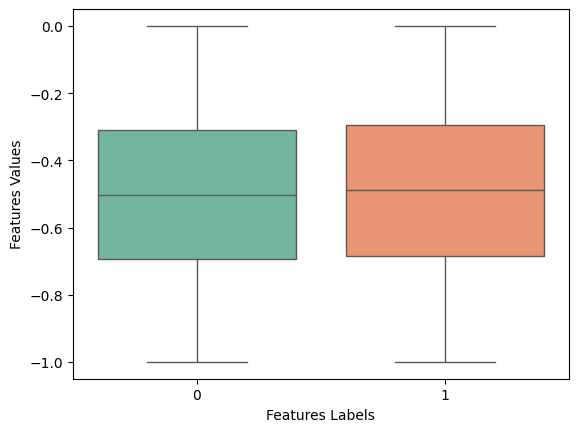

In [30]:
fig, ax = plt.subplots()
sns.boxplot(X_circles_iqc_coluna, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_circles_iqc_coluna.svg')

#### Boxplot Dataset Line Normalized

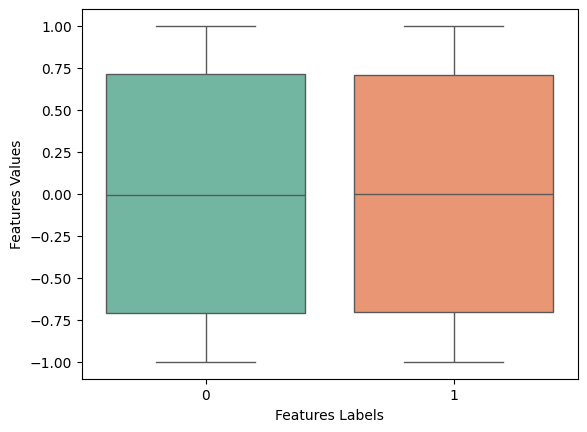

In [31]:
fig, ax = plt.subplots()
sns.boxplot(X_circles_iqc_linha, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_circles_iqc_linha.svg')

## Quantum Circuit

Não geraremos imagens ainda

### Circuito IQC em Qiskit

X[168]: [np.float64(0.34643152241741626), np.float64(0.3852512828956285)] ; w: [1 1] 

sigmaE
[[0.34643152 0.        ]
 [0.         0.38525128]]


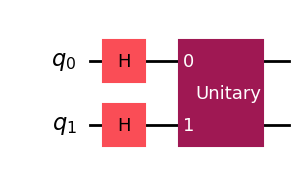

In [7]:
# Criando o circuito com um vetor qualquer do dataset para exemplificar

N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_circles))]
j=int(np.random.choice(lista))

w=weights

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=N_QUBITS

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

# IQC

qc = QuantumCircuit(N_qubits)
qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(range(1,N_qubits))



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_circles_new=list(X_circles[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_circles_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_circles_new)*w.T
else:
    sigmaE=np.diag(X_circles_new)*w.T

#Debugando
print(f'X[{j}]:', X_circles_new, '; w:', w,'\n')
print('sigmaE')
print(sigmaE)
#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(N_qubits)]
# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)
qc.draw("mpl")

{'u3': 6, 'cx': 2}


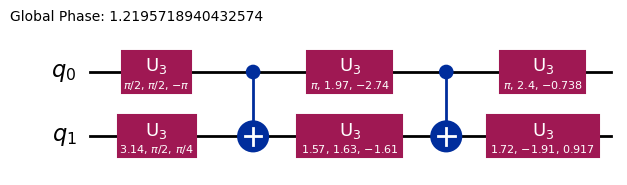

In [8]:
#Decompondo em portas U3 e CX
qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
print(dict(qc.count_ops()))
if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
    display(qc.draw('mpl'))

#### Statevector e Matriz Densidade

Aqui vamos avaliar o estado depois da evolução 

##### Statevector

<IPython.core.display.Latex object>

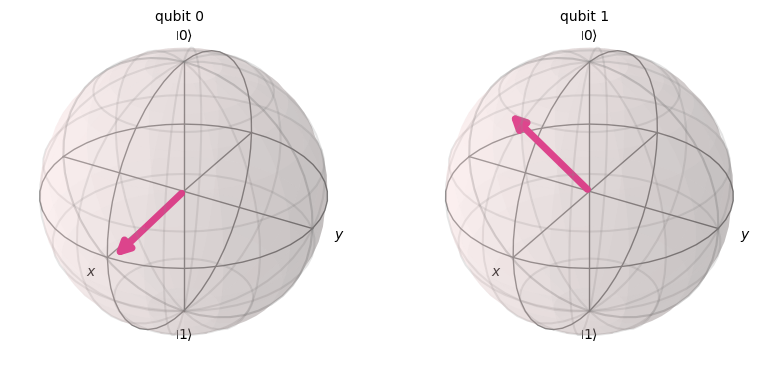

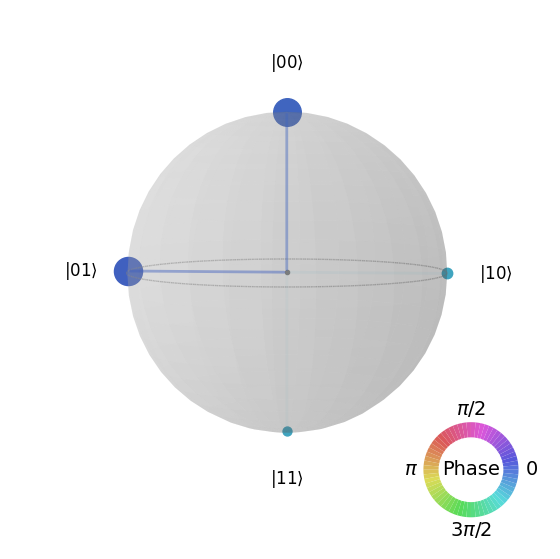

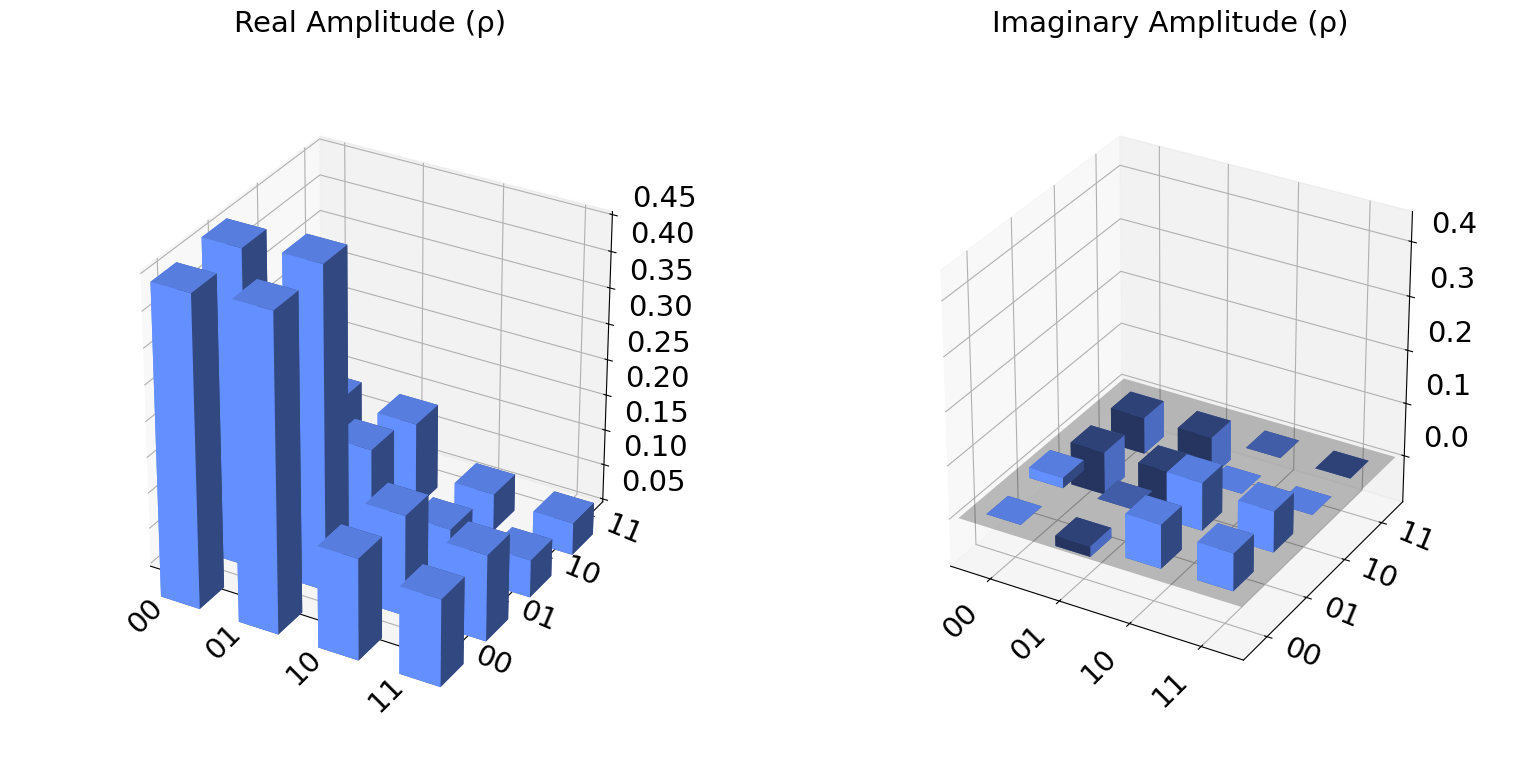

In [9]:
#Estado completo
sv = Statevector(qc)
'''
'mpl' is not a valid option for drawing Statevector objects. Please choose from:
            'text', 'latex', 'latex_source', 'qsphere', 'hinton',
            'bloch', 'city' or 'paulivec'
'''

display(sv.draw("latex")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("bloch")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("qsphere")) #Plota o vetor de estado em uma esfera que mapeia o espaço tensorial originado pelos espaços de Hilbert
display(sv.draw("city")) #Plota o histograma da matriz densidade SEM MEDÍ-LA


##### Partial Trace

Vamos traçar o sis. auxiliar

In [10]:
rho = partial_trace(sv,qubits[1:])
print(rho)

def blochvector(rho):
    x = np.trace(matriz_pauli_x@rho.data)
    y= np.trace(matriz_pauli_y@rho.data)
    z = np.trace(matriz_pauli_z@rho.data)
    return [x,y,z]
blochvector(rho)


DensityMatrix([[0.5      +0.j        , 0.4988702-0.01939526j],
               [0.4988702+0.01939526j, 0.5      +0.j        ]],
              dims=(2,))


[np.complex128(0.9977403907800628+0j),
 np.complex128(0.038790516908336015+0j),
 np.complex128(5.551115123125783e-16+0j)]

##### Ponto na Casca da superfície da Esfera de Bloch

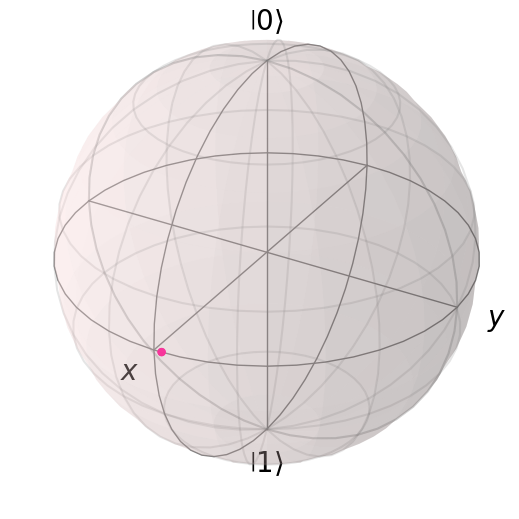

In [11]:
b = qutip.Bloch()
b.point_default_color=['deeppink']
b.add_points(blochvector(rho))

b.render()
b.show()

##### Matriz Densidade

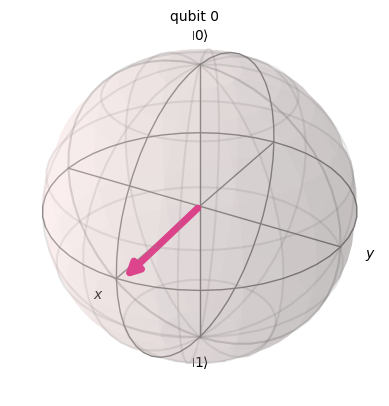

In [12]:
#Ao traçar fora o ambiente
rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
#rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:]).data

display(rho_res.draw('bloch'))

Como podemos observar, conseguimos marcar o ponto, na superfície da esfera, ao qual o autovetor do SISTEMA pertence. E se fizermos isso durante todo o código?

##### Negatividade

In [13]:
Negativity = (np.linalg.norm(rho_res)-1)/2

#### Executando o Circuito

{'00': 421, '01': 487, '11': 59, '10': 57}


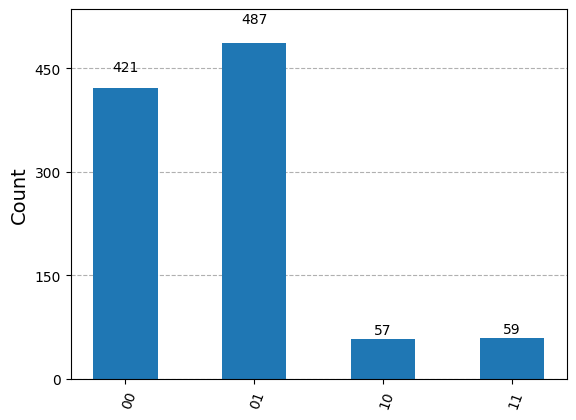

In [14]:
#Executar o circuito
def run_qasm_counts(circ, shots=1024):
  qc.measure_all()
  qasm_simulator = Aer.get_backend("qasm_simulator")
  job = qasm_simulator.run(qc, shots=shots)
  result = job.result()
  return result.get_counts()

counts = run_qasm_counts(qc)
print(counts)
plot_histogram(counts)

## Função que junta tudo até agora

In [32]:
def blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z):
    x_bloch = np.trace(matriz_pauli_x@rho_cog.data)
    y_bloch = np.trace(matriz_pauli_y@rho_cog.data)
    z_bloch = np.trace(matriz_pauli_z@rho_cog.data)
    return [x_bloch,y_bloch,z_bloch]
    
#Executar o circuito
def run_qasm_counts(qc, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def cirq_iqc(data,contador,w=weights,qubits=QUBITS, N_qubits=N_QUBITS,N_atributos=N_FEATURES,printar_cirq=False):

    X_circles_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_circles_new=np.append(X_circles_new,0)
        sigmaE=np.diag(X_circles_new)*w.T
    else:
        sigmaE=np.diag(X_circles_new)*w.T
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC

    qc = QuantumCircuit(N_qubits)

    qc.h(0)
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_circles_iqc.svg')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['cx']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_circles_iqc.svg')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['cx']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_circles_iqc.svg')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_circles_iqc.svg')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_circles_iqc.svg')
    if printar_cirq==True:
        display(sv.draw("latex"))
    
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_circles_iqc.svg')

    rho_cog = partial_trace(sv, qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    
    return blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z)

## Esfera de Bloch do Circuito

In [33]:
def esfera_bloch_IQC(X,norma=None,weights=weights,printar_esf=False):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq_iqc(X[k],k,w=weights))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    if norma:
        bb.savefig(f'Bloch_geral_circles_IQC_{norma}.svg')
    else:
        bb.savefig(f'Bloch_geral_circles_IQC.svg')

esfera_bloch_IQC(X_circles_iqc_coluna,'coluna')
esfera_bloch_IQC(X_circles_iqc_linha,'linha')
esfera_bloch_IQC(X_circles)